In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
file_path = r"C:\Users\parth\Downloads\archive\Unemployment in India.csv"

df = pd.read_csv(file_path)

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [6]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (768, 7)

Columns:
['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']

Data Types:
Region                                          str
 Date                                           str
 Frequency                                      str
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                         float64
 Estimated Labour Participation Rate (%)    float64
Area                                            str
dtype: object

Missing Values:
Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64


In [7]:
import os

os.listdir(r"C:\Users\parth\Downloads\archive")

['Unemployment in India.csv', 'Unemployment_Rate_upto_11_2020.csv']

In [8]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Remove rows with missing values
df = df.dropna()

# Convert Date column to datetime
df["Date"] = pd.to_datetime(
    df["Date"].astype(str).str.strip(),
    dayfirst=True,
    errors="coerce"
)

# Check the cleaned data
print("Shape after cleaning:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)

Shape after cleaning: (740, 7)

Missing values:
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64

Data types:
Region                                                str
Date                                       datetime64[us]
Frequency                                             str
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                float64
Estimated Labour Participation Rate (%)           float64
Area                                                  str
dtype: object


In [9]:
region_avg = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
)

print(region_avg)

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64


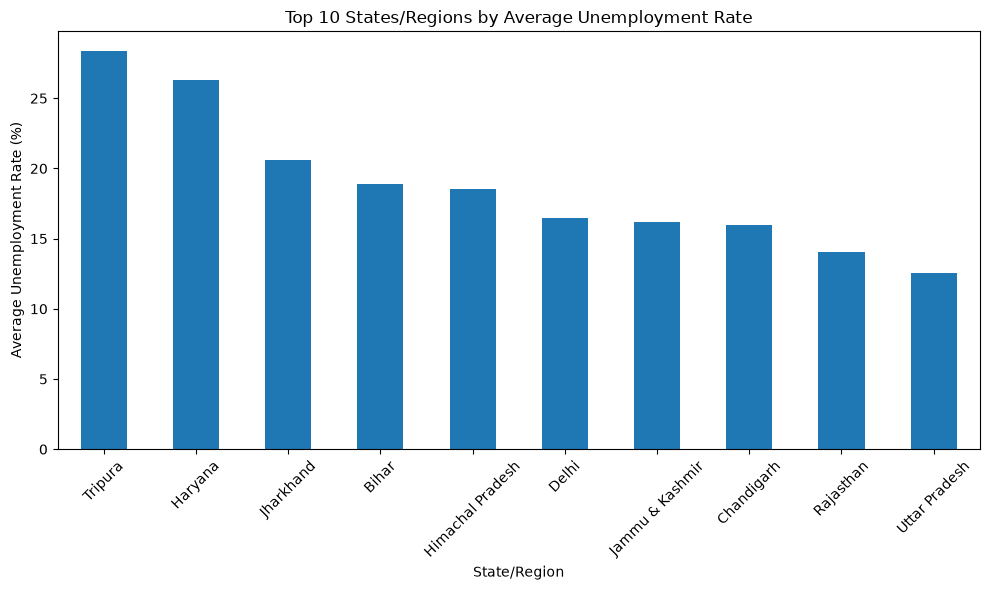

In [10]:
top_10 = region_avg.head(10)

plt.figure(figsize=(10, 6))
top_10.plot(kind="bar")

plt.title("Top 10 States/Regions by Average Unemployment Rate")
plt.xlabel("State/Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

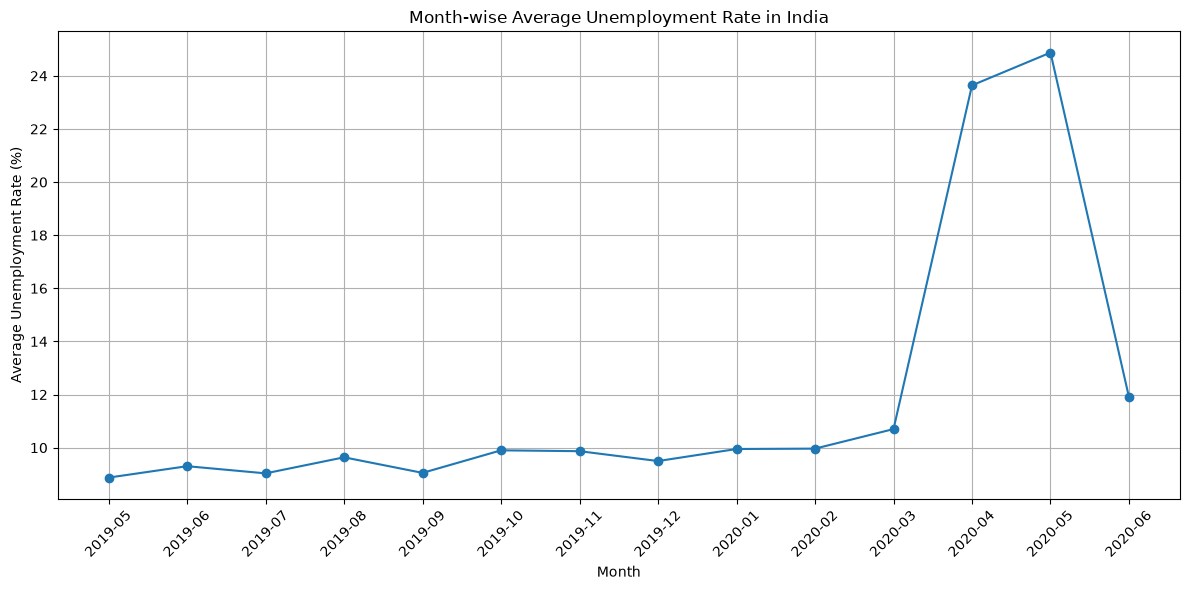

In [11]:
monthly_avg = (
    df.groupby(df["Date"].dt.to_period("M"))["Estimated Unemployment Rate (%)"]
    .mean()
)

monthly_avg.index = monthly_avg.index.astype(str)

plt.figure(figsize=(12, 6))
plt.plot(monthly_avg.index, monthly_avg.values, marker="o")

plt.title("Month-wise Average Unemployment Rate in India")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

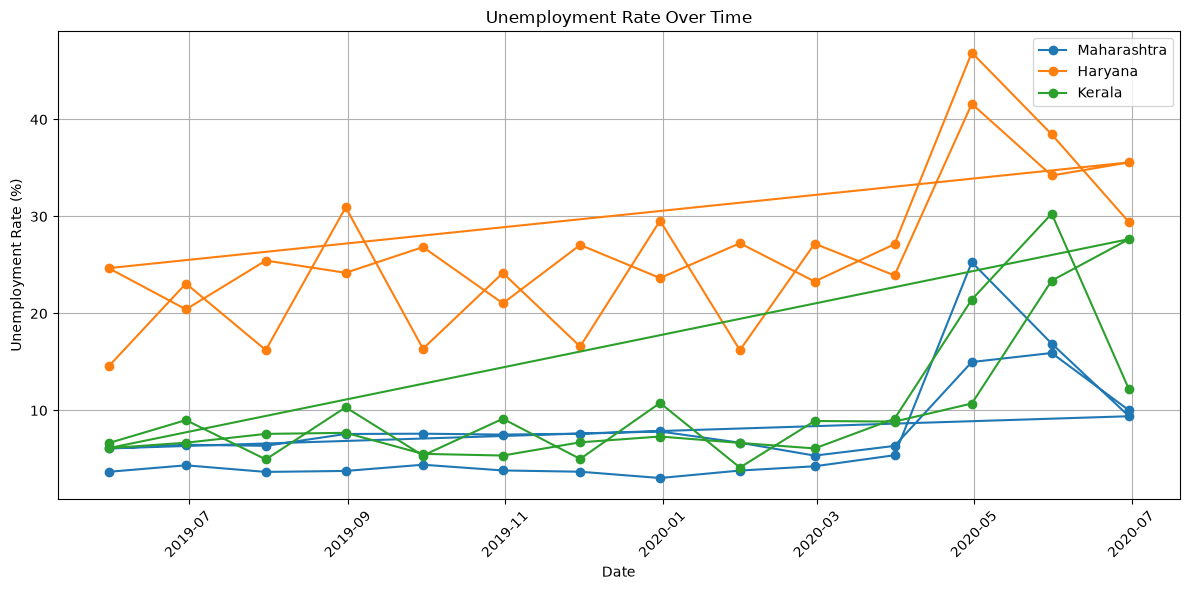

In [12]:
states = ["Maharashtra", "Haryana", "Kerala"]

plt.figure(figsize=(12, 6))

for state in states:
    state_data = df[df["Region"] == state]
    plt.plot(
        state_data["Date"],
        state_data["Estimated Unemployment Rate (%)"],
        marker="o",
        label=state
    )

plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

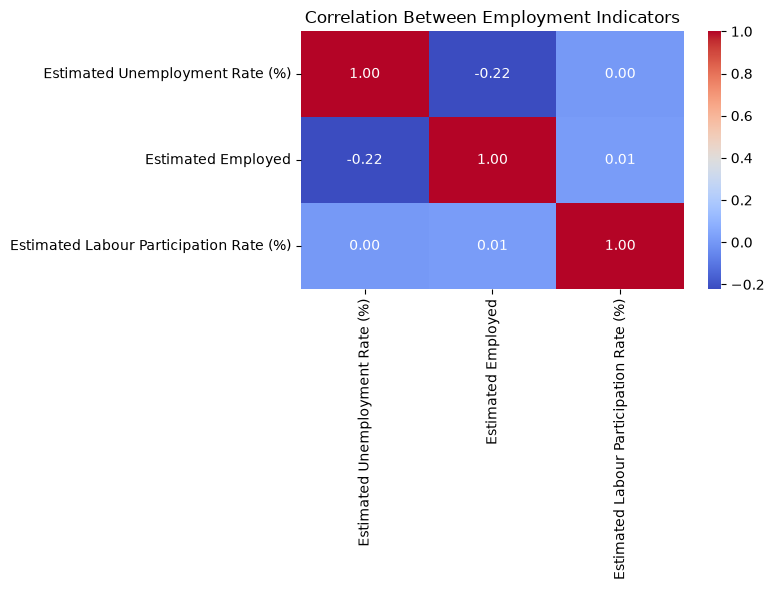

In [13]:
corr = df[
    [
        "Estimated Unemployment Rate (%)",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"
    ]
].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Employment Indicators")
plt.tight_layout()
plt.show()

In [14]:
pre_covid = df[df["Date"] < "2020-03-01"]
post_covid = df[df["Date"] >= "2020-03-01"]

comparison = pd.DataFrame({
    "Period": ["Pre-COVID", "Post-COVID"],
    "Average Unemployment Rate (%)": [
        pre_covid["Estimated Unemployment Rate (%)"].mean(),
        post_covid["Estimated Unemployment Rate (%)"].mean()
    ],
    "Average Labour Participation Rate (%)": [
        pre_covid["Estimated Labour Participation Rate (%)"].mean(),
        post_covid["Estimated Labour Participation Rate (%)"].mean()
    ]
})

comparison

,Period,Average Unemployment Rate (%),Average Labour Participation Rate (%)
0,Pre-COVID,9.509534,43.886119
1,Post-COVID,17.774363,39.330049


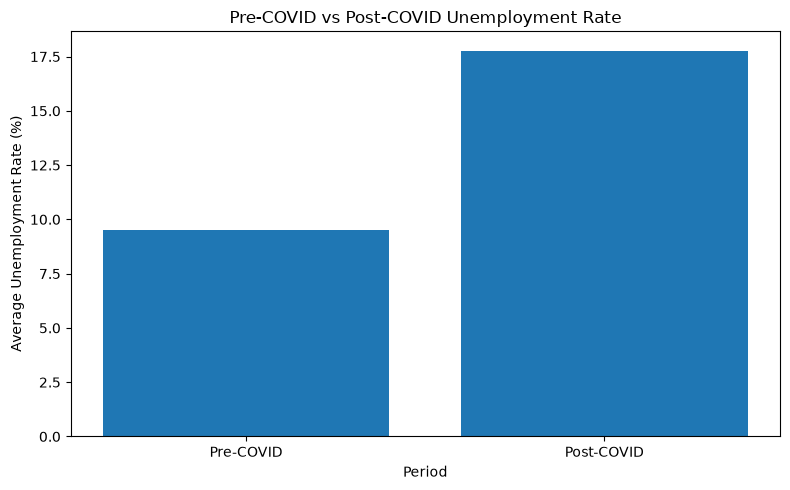

In [15]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Period"],
    comparison["Average Unemployment Rate (%)"]
)

plt.title("Pre-COVID vs Post-COVID Unemployment Rate")
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")

plt.tight_layout()
plt.show()

## Observations

- The average unemployment rate varies across different states and regions in India.
- The top 10 regions show noticeable differences in their average unemployment rates.
- The month-wise trend shows that unemployment rates changed over time, with noticeable variation during the COVID-19 period.
- The time-series comparison of Maharashtra, Haryana, and Kerala shows different unemployment patterns across the three regions.
- The correlation heatmap shows the relationship between unemployment rate, employment, and labour participation rate.
- The Pre-COVID and Post-COVID comparison shows a change in the average unemployment rate between the two periods.
- Overall, the analysis highlights regional and temporal variations in unemployment in India.